In [1]:
from teleconnections import station_based_index, reg_evaluation, cor_evaluation
from teleconnections.plots import plot_single_map, index_plot

function/symbol 'fdb_delete_splitkey' not found in library 'libfdb5.so.0d': /lib/x86_64-linux-gnu/libfdb5.so.0d: undefined symbol: fdb_delete_splitkey
Error retrieving attribute fdb_delete_splitkey from library
function/symbol 'fdb_listiterator_attrs' not found in library 'libfdb5.so.0d': /lib/x86_64-linux-gnu/libfdb5.so.0d: undefined symbol: fdb_listiterator_attrs
Error retrieving attribute fdb_listiterator_attrs from library
function/symbol 'fdb_listiterator_splitkey' not found in library 'libfdb5.so.0d': /lib/x86_64-linux-gnu/libfdb5.so.0d: undefined symbol: fdb_listiterator_splitkey
Error retrieving attribute fdb_listiterator_splitkey from library
function/symbol 'fdb_new_splitkey' not found in library 'libfdb5.so.0d': /lib/x86_64-linux-gnu/libfdb5.so.0d: undefined symbol: fdb_new_splitkey
Error retrieving attribute fdb_new_splitkey from library
function/symbol 'fdb_splitkey_next_metadata' not found in library 'libfdb5.so.0d': /lib/x86_64-linux-gnu/libfdb5.so.0d: undefined symbol: 

In [2]:
%reload_ext autoreload
%autoreload 2

In [16]:
import xarray as xr
import cftime

file_pattern_pi = '/archive/paolo/cmip6/CMIP6/model-output/EC-Earth-Consortium/EC-Earth3-LR/piControl/atmos/Amon/r1i1p1f1/psl/psl_Amon_EC-Earth3-LR_piControl_r1i1p1f1_gr_*.nc'
file_pattern_mid = '/archive/paolo/cmip6/CMIP6/model-output/EC-Earth-Consortium/EC-Earth3-LR/midHolocene/atmos/Amon/r1i1p1f1/psl/psl_Amon_EC-Earth3-LR_midHolocene_r1i1p1f1_gr_*.nc'

ds_pi = xr.open_mfdataset(file_pattern_pi, use_cftime=True, decode_times=True)
ds_mid = xr.open_mfdataset(file_pattern_mid, use_cftime=True, decode_times=True)

In [4]:
from teleconnections import TeleconnectionsConfig

config = TeleconnectionsConfig()
namelist = config.load_namelist()

In [17]:
indx_pi = station_based_index(field=ds_pi.psl, namelist=namelist)

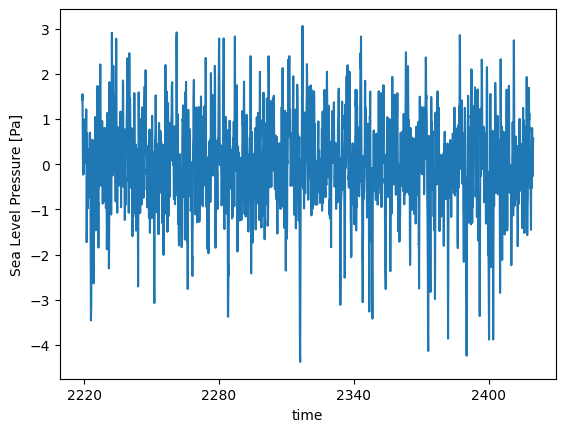

In [18]:
indx_pi.plot()

In [19]:
reg_pi = reg_evaluation(data=ds_pi.psl, indx=indx_pi)

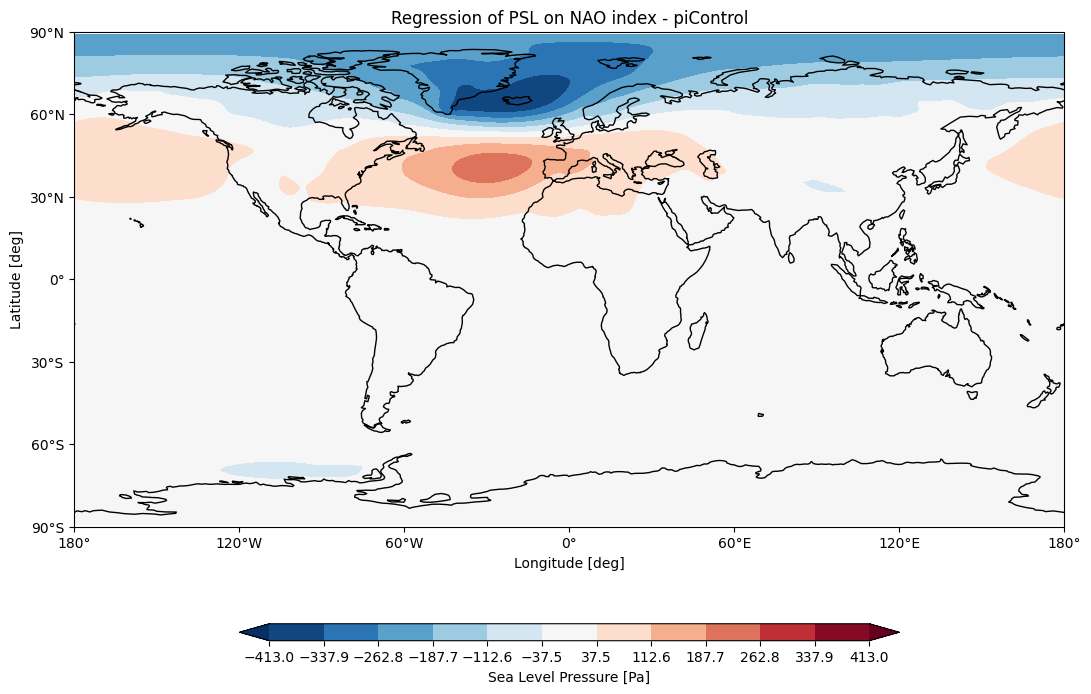

In [20]:
plot_single_map(reg_pi, title='Regression of PSL on NAO index - piControl', save=True, filename='regression_psl_nao_piControl.png')

In [12]:
indx_mid = station_based_index(field=ds_mid.psl, namelist=namelist)

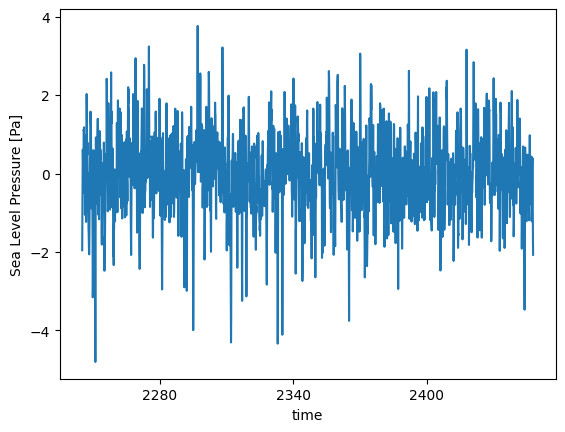

In [13]:
indx_mid.plot()

In [14]:
reg_mid = reg_evaluation(data=ds_mid.psl, indx=indx_mid)

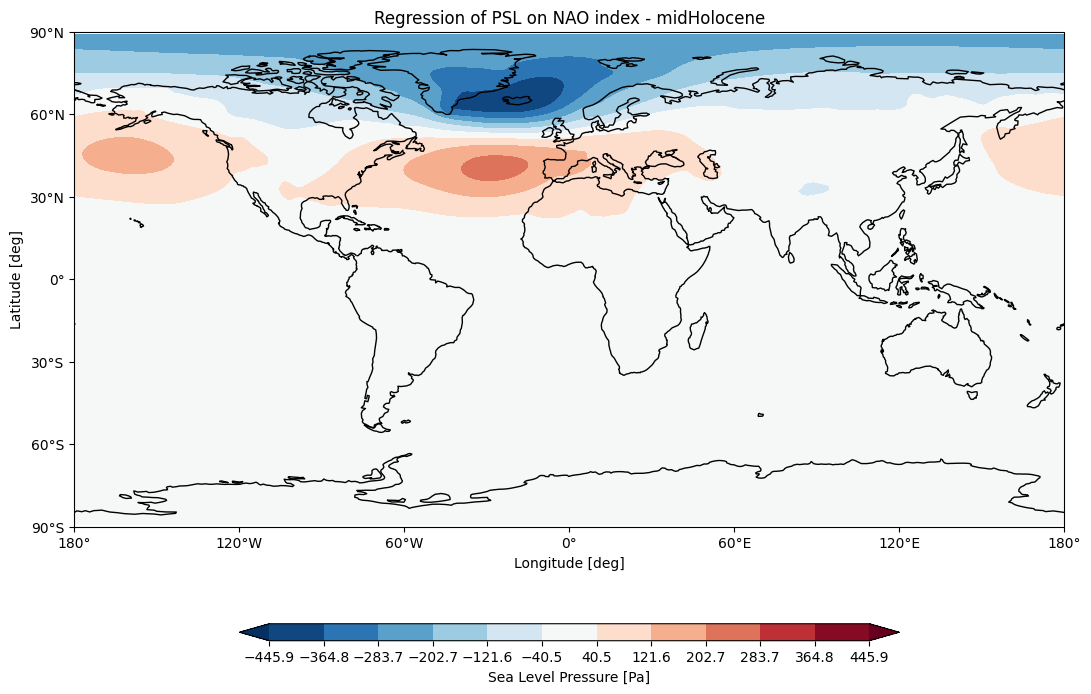

In [15]:
plot_single_map(reg_mid, title='Regression of PSL on NAO index - midHolocene', save=True, filename='regression_psl_nao_midHolocene.png')

In [21]:
from teleconnections import maps_plot

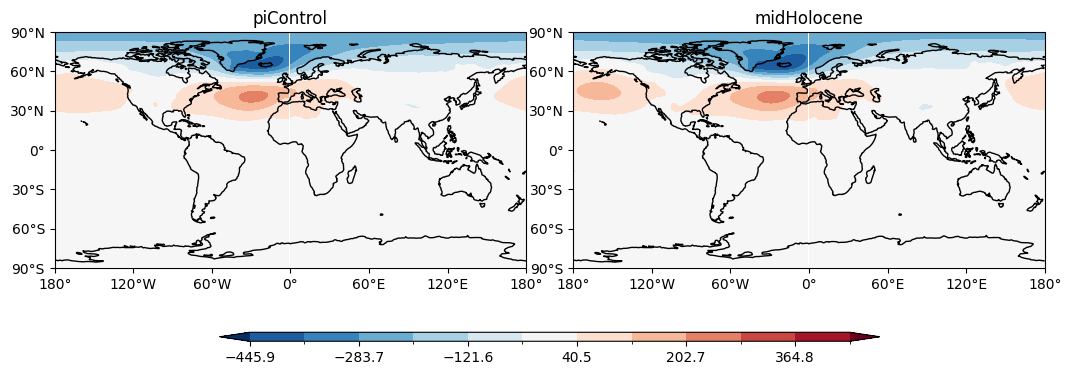

In [25]:
maps_plot(maps=[reg_pi, reg_mid], titles=['piControl', 'midHolocene'], save=True, filename='regression_psl_nao_piControl_midHolocene.pdf', figsize=(11, 4.5))